plot 2

- Separate plot: Subset 30 neurons and add regression line for each of them (number of points per neuron in the regression = number of images). If messy, decrease to 10 neurons

plot 3

- Separate plot: all neurons: histogram = distribution of regression slopes (number of points = number of neurons)

plot 4

- Now combined plot: plot as kernel density all distribution of slopes for each sigmaXnoise condition (6 lines)
- all neurons

#### environment

In [1]:
import os 
import numpy as np
from numpy import full
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
#from predict_loop_functions import predict_loop, noise_iterations 
from predict_loop_functions import remove_x
from scipy.stats import linregress, gaussian_kde

In [2]:
# use image stack from july16 already saved
image_stack = np.load('saved_inputs_outputs//image_stack_july16.npy')

In [3]:
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
                    1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

#### predictions

In [ ]:
d3_sum, d3_mean, d3_var, d3_labels = predict_loop('dynamic', image_stack, 3, [[4,7]])

In [ ]:
d15_sum, d15_mean, d15_var, d15_labels = predict_loop('dynamic', image_stack, 15, [[4,7]])

In [ ]:
d30_sum, d30_mean, d30_var, d30_labels = predict_loop('dynamic', image_stack, 30, [[4,7]])

In [ ]:
c3_sum, c3_mean, c3_var, c3_labels = predict_loop('constant', image_stack, 3, [[4,7]])

In [ ]:
c15_sum, c15_mean, c15_var, c15_labels = predict_loop('constant', image_stack, 15, [[4,7]])

In [ ]:
c30_sum, c30_mean, c30_var, c30_labels = predict_loop('constant', image_stack, 30, [[4,7]])

In [ ]:
dbin_sum, dbin_mean, dbin_var, dbin_labels = predict_loop('dynamic', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [ ]:
cbin_sum, cbin_mean, cbin_var, cbin_labels = predict_loop('constant', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [ ]:
# save predictions to predictions_july21
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin']:
    for type_output in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type_output
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        np.save(path, arr = globals()[file_name])

##### add no noise prediction for turning curves

In [ ]:
no_noise_sum, no_noise_mean, no_noise_var, no_noise_labels = predict_loop('no noise', image_stack, 0, [[4,7]])

In [ ]:
for type in ['_sum', '_mean', '_var', '_labels']:
        file_name = 'no_noise' + type
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        np.save(path, arr = globals()[file_name])

#### load predictions

In [2]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_noise in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type_noise + '.npy'
        var_name = noise + type_noise
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        globals()[var_name] = np.load(path)

In [3]:
# load predictions by region
for region in np.unique(d3_labels):
    for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
        for type_noise in ['_sum', '_mean', '_var']:
            file_name = noise + type_noise + '_r' + str(region) +  '.npy'
            path = 'saved_inputs_outputs//predictions_july21//' + file_name
            array_name = noise + type_noise + '_r' + str(region)
            globals()[array_name] = np.load(path)

##### 30 random neurons for each region

In [4]:
# region 1
r1_randoms = [2322, 3279, 4060, 1756,  146, 4441, 3978, 2034, 5025, 3515, 3534,
       2167, 2310, 1837, 3864, 2529, 4127, 2325, 4791,  314, 3371, 1857,
       1095, 1917, 3097, 1722, 4344, 3627, 3930, 3459]

In [5]:
# region 2
r2_randoms = [958, 907, 514, 432, 594, 385, 184, 368, 525, 351, 302, 551, 550,
       575, 375, 719, 242, 613, 789, 872, 340, 402, 397, 643, 255, 928,
       471, 894, 281, 523]

In [6]:
# region 3
r3_randoms = [279, 337, 208, 128,  46, 115, 248, 197,  52, 269,  37, 364, 340,
       203,  36, 153,  84, 278,  71, 115,  24,  78, 138,  38,  22,  17,
        89, 349, 178, 332]

In [7]:
# region 4
r4_randoms = [376, 295, 517,  25, 663, 429, 427, 651, 133, 500, 689, 266, 470,
       424,  90, 560, 290, 198, 149, 181, 749, 461, 658, 771, 367, 758,
       125, 195, 191,   8]

#### plot 2

In [89]:
# plot 10 random neurons and put regression, make sure neurons is list of random neurons for each region
# input must be 2D LIST of prediction seperated by region
def mean_var_scatter_4x4_regression(means, vars, neurons, main_title: str, savefig: bool = False):
    fig, axes = plt.subplots(4, 4, figsize=(12, 10), sharex=False, sharey=False)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=12, fontweight = 'bold', bbox=dict(facecolor='white'))
    sigmas = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']
    
    for i in range(4):
        neuron_arr = neurons[i]
        for j in range(4):
            idx = i * 4 + j
            ax = axes[i, j] # first iterate j through different sigmas
            

            x = np.array(means[i][j])
            y = np.array(vars[i][j])
            for neuron in neuron_arr:
                x_neuron = x[:, neuron]
                y_neuron = y[:, neuron]
                
                cmap = plt.get_cmap('plasma')

                color_i = neuron_arr.index(neuron) / (len(neuron_arr) - 1)
                colors = cmap(color_i)
                               
                ax.scatter(x_neuron, y_neuron, marker='.', color = colors, alpha = 0.4)

                linregress_result = linregress(x_neuron, y_neuron)
                x_fit = np.linspace(np.min(x_neuron), np.max(x_neuron), len(x_neuron))
                y_fit = linregress_result.intercept + linregress_result.slope * x_fit

                ax.plot(x_fit, y_fit, color=colors, label='Regression line', linewidth=2)           
                
                ax.grid(True)

                if i == 0: title_region = 'V1' 
                elif i == 1: title_region = 'LM'
                elif i == 2: title_region = 'AL'
                else: title_region = 'RL'

                if j == 0: ax.set_ylabel(f'Variance in\nPredicted Spike Count', fontsize = 11)
                
                if i == 0: ax.set_title(f'({sigmas[j]})', fontsize = 10)
                elif i == 3: ax.set_xlabel('Mean Predicted\nSpike Count', fontsize = 12)  
    
    fig.text(0, -0.01, 'Note: Colors represent same neuron within each region.', 
             ha='left', va='bottom', fontsize=12)


    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: plt.show()

closer look at region 2 mean predictions

from debugging we know neuron 523 from the second region is the only neuron to have a mean >100

In [90]:
d3_mean_r2[:, 523]

array([  7.3212864 ,   4.17064615, 144.30993432,   5.43207267,
         2.42184805])

In [91]:
d15_mean_r2[:, 523]

array([6.56672324, 2.61516894, 9.16808018, 3.59682721, 2.00921645])

In [92]:
scatter_means = [[d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1],
          [d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2],
          [d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3],
          [d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]]
scatter_vars = [[d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1],
        [d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2],
        [d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3],
        [d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]]


In [93]:
randoms = [r1_randoms, r2_randoms, r3_randoms, r4_randoms]

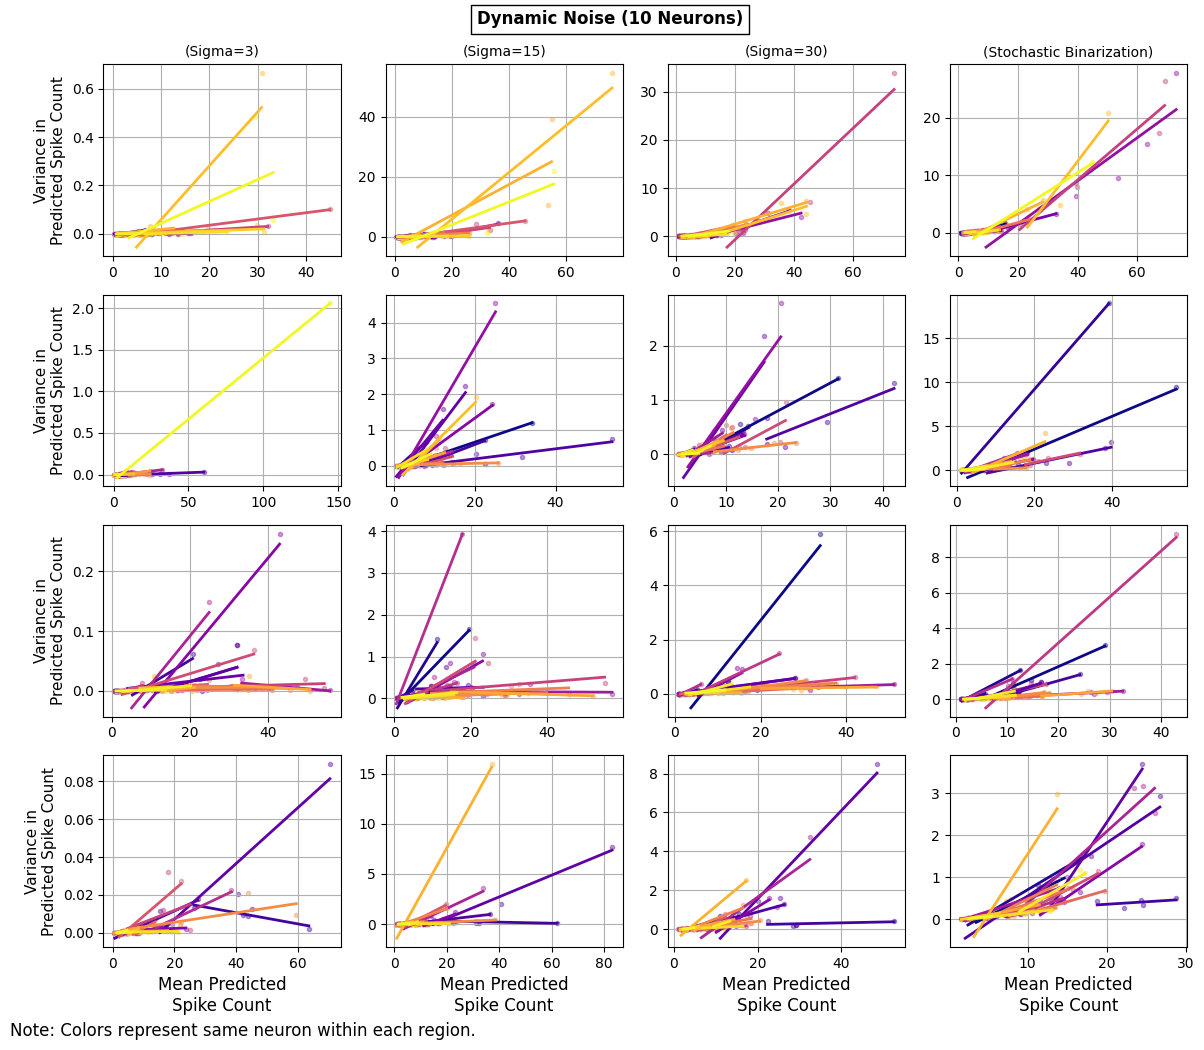

In [94]:
mean_var_scatter_4x4_regression(scatter_means, scatter_vars, randoms[:10], 'Dynamic Noise (10 Neurons)', False)

In [95]:
scatter_means = [[c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1],
                 [c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2],
                 [c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3],
                 [c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]]

scatter_vars = [[c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1],
               [c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2],
               [c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3],
               [c3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]]


In [96]:
randoms = [r1_randoms, r2_randoms, r3_randoms, r4_randoms]

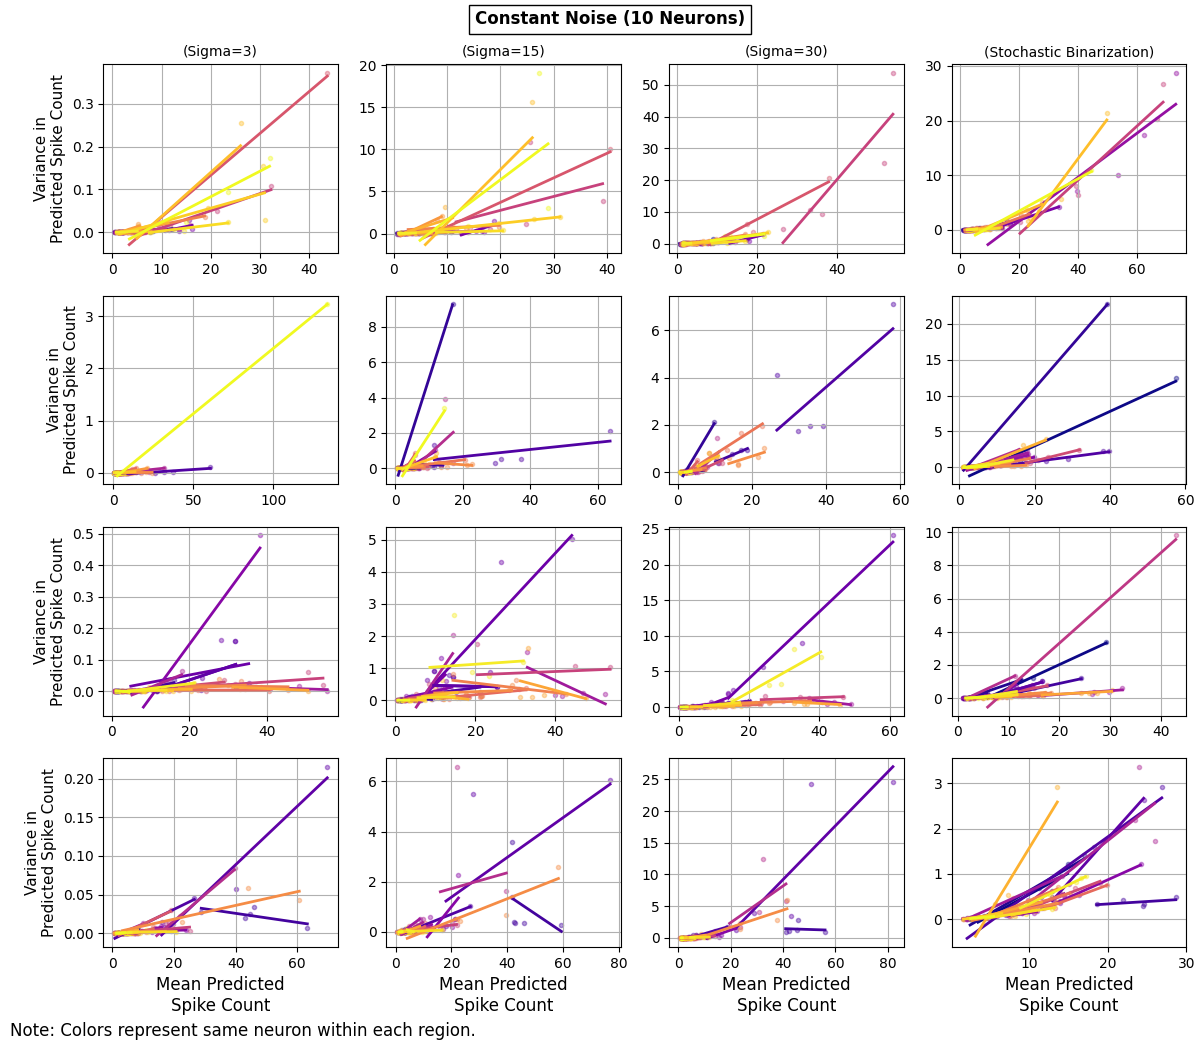

In [98]:
mean_var_scatter_4x4_regression(scatter_means, scatter_vars, randoms[:10], 'Constant Noise (10 Neurons)')

#### plot 3

##### 4x4 hist

In [78]:
def mean_var_hist_4x4(means, vars, main_title: str):
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=12, fontweight = 'bold', bbox=dict(facecolor='white'))
    sigmas = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']
    cmap = plt.get_cmap('viridis')
    row_colors = [cmap(0.2), cmap(0.4), cmap(0.6), cmap(0.8)] 

    for i in range(4):
        for j in range(4):
            idx = i * 4 + j
            ax = axes[i, j] 
            
            x = means[idx]
            y = vars[idx]
            slope_arr = np.empty((x.shape[1]))

            for neuron in range(y.shape[1]):
                regression = linregress(x[:, neuron], y[:, neuron])
                slope_arr[neuron] = regression.slope                   

            ax.hist(slope_arr, bins = 50, color = row_colors[i])

            if i == 0: title_region = 'V1' 
            elif i == 1: title_region = 'LM'
            elif i == 2: title_region = 'AL'
            else: title_region = 'RL'

            if j == 0:
                ax.set_ylabel(f'(Region: {title_region})\n\nCount')
            if i == 3:
                ax.set_xlabel(f'Slope from\nMean Variance Regression\n\n({sigmas[j]})')  
    
    plt.tight_layout()
    plt.show()

In [79]:
scatter_means = [d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1,
                 d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2,
                 d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3,
                 d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]


In [80]:
scatter_vars = [d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1,
               d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2,
               d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3,
               d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]


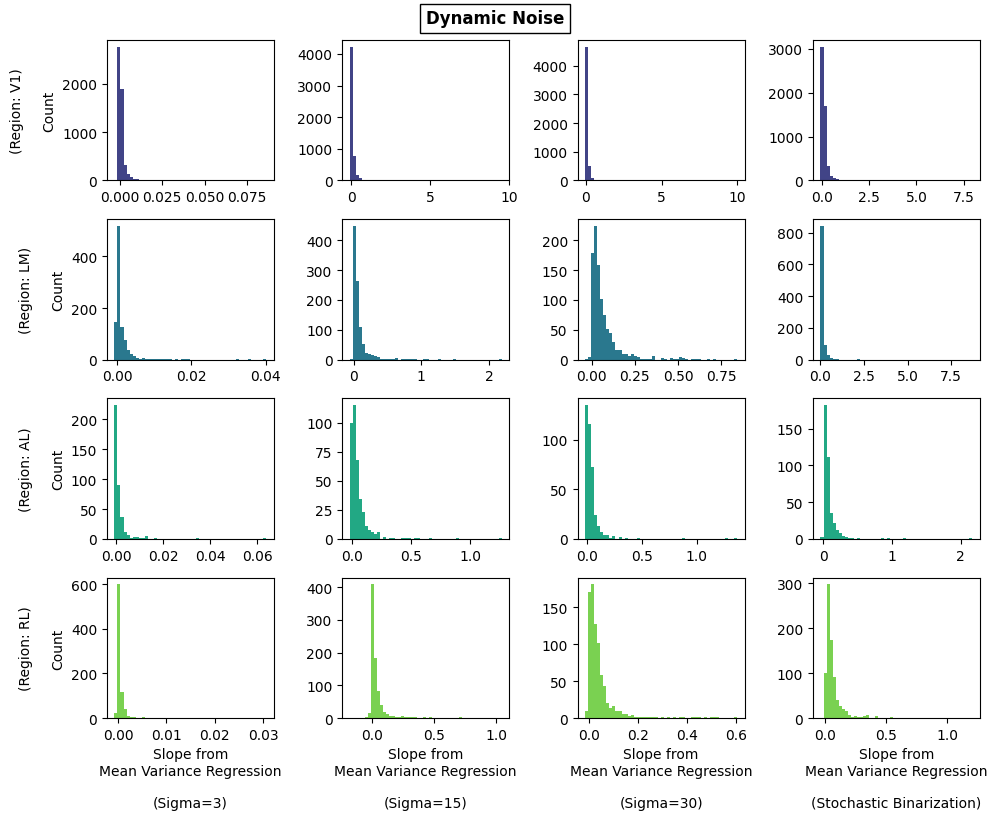

In [81]:
mean_var_hist_4x4(scatter_means, scatter_vars, 'Dynamic Noise')

In [ ]:
scatter_means = [c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1,
                 c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2,
                 c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3,
                 c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]


In [ ]:
scatter_vars = [c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1,
               c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2,
               c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3,
               c3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]


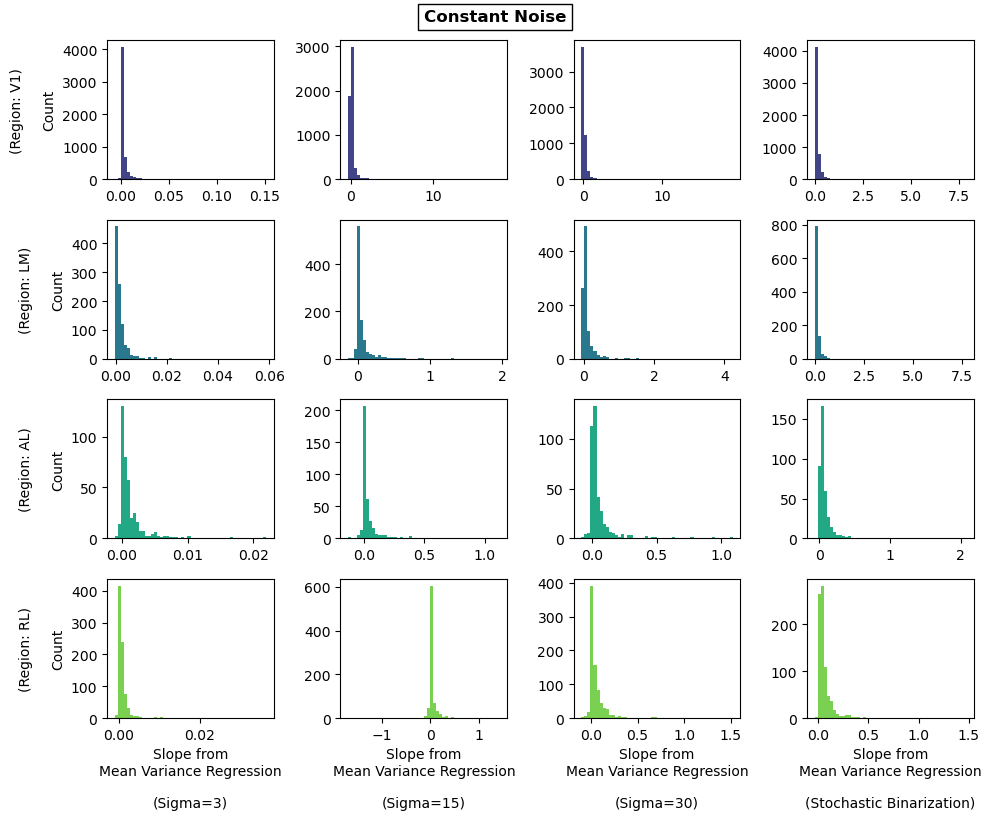

In [ ]:
mean_var_hist_4x4(scatter_means, scatter_vars, 'Constant Noise')

##### violin plot 1

In [69]:
def violin_4x1(means, vars, main_title: str, savefig: bool = False, remove_x_str: str = None, remove_x_percent: int = None): # assume array inputs are 2d
    fig, axes = plt.subplots(len(means), 1, figsize=(10, 8), sharex=True, sharey=False)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=12, fontweight = 'bold', bbox=dict(facecolor='white'))
    violin_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
    violin_colors = [violin_colors[i] for i in range(len(means))]
    for i in range(len(means)):
        ax = axes[i] 
        
        region_x = means[i]
        region_y = vars[i]
        slope_list = []

        for mean_arr, var_arr in zip(region_x, region_y):
            slope_temp = []
            for neuron in range(mean_arr.shape[1]):
                neuron_x = mean_arr[:, neuron]
                neuron_y = var_arr[:, neuron]
                linregress_neuron = linregress(neuron_x, neuron_y)
                slope_temp.append(linregress_neuron.slope)
            slope_list.append(slope_temp)
        
        # method 1, remove x
        if remove_x is not None and remove_x_percent is not None:
            for region_slopes in slope_list:
                region_slopes = remove_x(region_slopes, remove_x_str, remove_x_percent)

        vp = ax.violinplot(slope_list, showmeans = False, showmedians = True, showextrema = False,
                           quantiles = [[0.25, 0.75] for _ in range(len(slope_list))])


        for body in vp['bodies']:
            body.set_facecolor(violin_colors[i])
        for element in ['cmedians']:
            vp[element].set_color('black')
                
        for element in ['cquantiles', 'cmedians']: vp[element].set_linewidth(0.5)

        if i == 0: title_region = 'V1' 
        elif i == 1: title_region = 'LM'
        elif i == 2: title_region = 'AL'
        else: title_region = 'RL'

        ax.set_ylabel(f'(Region: {title_region})\nRegression Slope', fontsize = 10)
        
        tick_labels = ['15', '30', 'Stochastic\nBinarization']
        if i == 3: ax.set_xticks([i+1 for i, _ in enumerate(tick_labels)])
        if i == 3: ax.set_xticklabels(tick_labels)  
        if i == 3: ax.set_xlabel('Sigma + Binarization')
        
        # method 2, set y_lim
        if i == 0 or i == 1: ax.set_ylim(0, 0.1 * max([np.max(arr) for arr in slope_list]))
        else: ax.set_ylim(0, 0.2 * max([np.max(arr) for arr in slope_list]))

    plt.text(0, -.075, 'Note: lines within each plot show the interquartile range and median.')
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: plt.show()

In [71]:
scatter_means = [[d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1],
                 [d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2],
                 [d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3],
                 [d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]]

scatter_vars = [[d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1],
               [d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2],
               [d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3],
               [d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]]

In [72]:
scatter_means = [[d15_mean_r1, d30_mean_r1, dbin_mean_r1],
                 [d15_mean_r2, d30_mean_r2, dbin_mean_r2],
                 [d15_mean_r3, d30_mean_r3, dbin_mean_r3],
                 [d15_mean_r4, d30_mean_r4, dbin_mean_r4]]

scatter_vars = [[d15_var_r1, d30_var_r1, dbin_var_r1],
               [d15_var_r2, d30_var_r2, dbin_var_r2],
               [d15_var_r3, d30_var_r3, dbin_var_r3],
               [d15_var_r4, d30_var_r4, dbin_var_r4]]

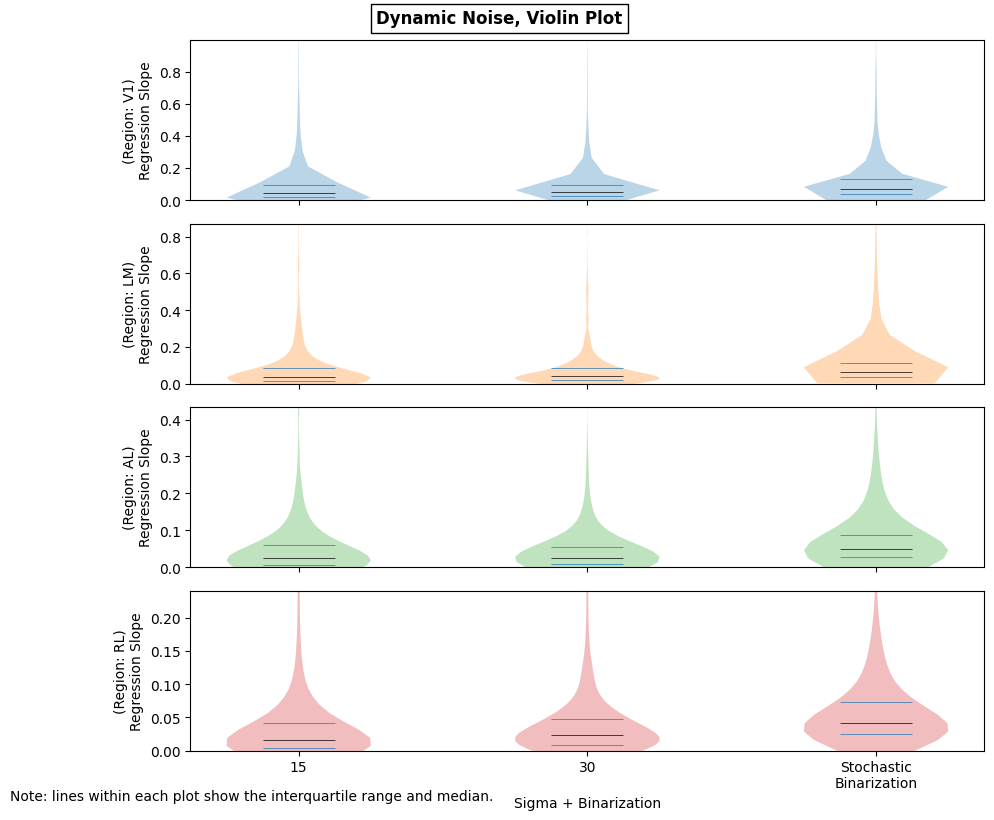

In [73]:
violin_4x1(scatter_means, scatter_vars, 'Dynamic Noise, Violin Plot', savefig = False)

In [74]:
cscatter_means = [[c15_mean_r1, c30_mean_r1, cbin_mean_r1],
                 [c15_mean_r2, c30_mean_r2, cbin_mean_r2],
                 [c15_mean_r3, c30_mean_r3, cbin_mean_r3],
                 [c15_mean_r4, c30_mean_r4, cbin_mean_r4]]


In [75]:
cscatter_vars = [[c15_var_r1, c30_var_r1, cbin_var_r1],
               [c15_var_r2, c30_var_r2, cbin_var_r2],
               [c15_var_r3, c30_var_r3, cbin_var_r3],
               [c15_var_r4, c30_var_r4, cbin_var_r4]]

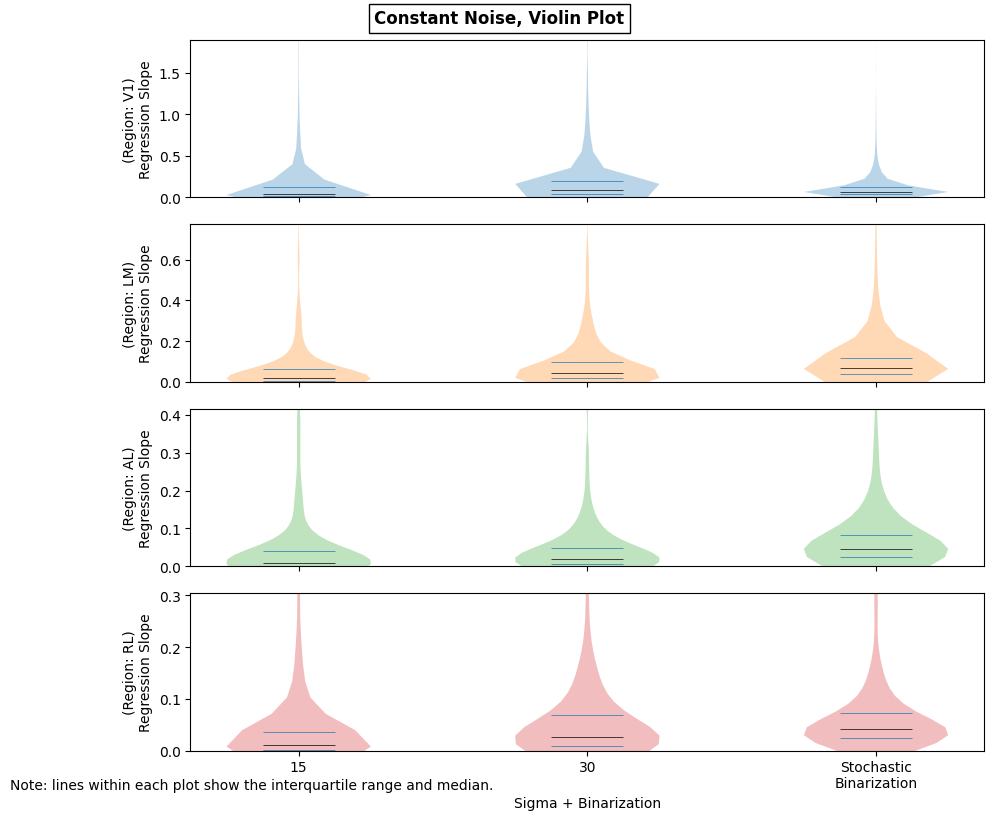

In [77]:
violin_4x1(cscatter_means, cscatter_vars, 'Constant Noise, Violin Plot', savefig = False)

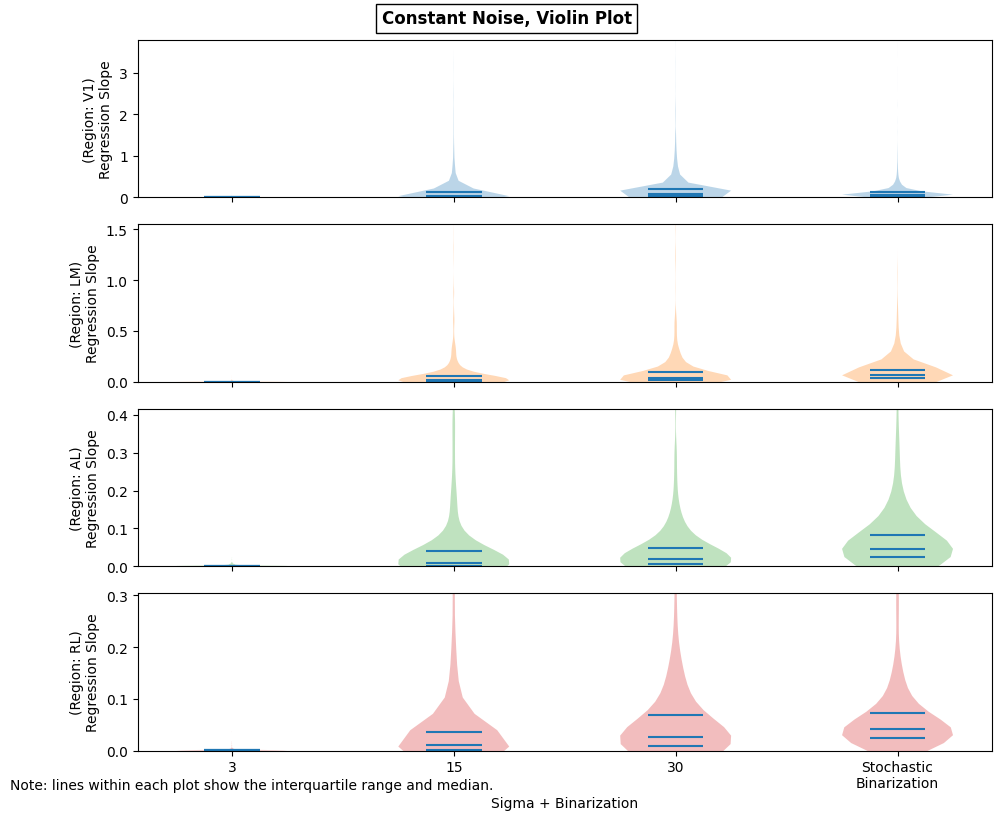

In [199]:
violin_4x1(cscatter_means, cscatter_vars, 'Constant Noise, Violin Plot',savefig = True)

##### violin plot 2

In [ ]:
def violin_combined(means, vars, main_title: str, savefig: bool = False):
    # Create figure and single axes
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Define region names and colors
    regions = ['V1', 'LM', 'AL', 'RL']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
    
    all_slope_lists = []
    for i in range(len(means)):
        region_x = means[i]
        region_y = vars[i]
        slope_list = []
        
        for mean_arr, var_arr in zip(region_x, region_y):
            slope_temp = []
            for neuron in range(mean_arr.shape[1]):
                neuron_x = mean_arr[:, neuron]
                neuron_y = var_arr[:, neuron]
                linregress_neuron = linregress(neuron_x, neuron_y)
                slope_temp.append(linregress_neuron.slope)
            slope_list.append(slope_temp)
        all_slope_lists.append(slope_list)
    
    # Prepare data for violin plot: combine slopes for all regions
    num_conditions = len(all_slope_lists[0])  # Number of sigma conditions (e.g., 4)
    violin_data = []
    positions = []
    violin_colors = []
    for cond in range(num_conditions):
        # Add slopes for each region for this condition
        for region_idx in range(len(regions)):
            violin_data.append(all_slope_lists[region_idx][cond])
            # Calculate position with slight offset for each region
            base_pos = cond + 1  # Base position for condition (1, 2, 3, 4)
            offset = (region_idx - (len(regions) - 1) / 2) * 0.2  # Offset within group
            positions.append(base_pos + offset)
            violin_colors.append(colors[region_idx])
    
    # Create violin plot
    vp = ax.violinplot(violin_data, positions=positions, showextrema = False, quantiles = [[0.25, 0.75] for _ in range(len(violin_data))],
                       showmeans=True, showmedians=True, widths=0.2, bw_method = 0.8)
    
    # Color each violin body
    for i, body in enumerate(vp['bodies']):
        body.set_facecolor(violin_colors[i])
        body.set_edgecolor('black')
        body.set_alpha(0.7)
    
    # Customize statistical markers
    vp['cmeans'].set_color('yellow')
    vp['cmedians'].set_color('white')
    
    # Customize x-axis ticks and labels
    ax.set_xticks(range(1, num_conditions + 1))
    ax.set_xticklabels(['3', '15', '30', 'Stochastic\nBinarization'])
    ax.set_xlabel('Sigma + Binarization', fontsize=10)
    
    # Customize y-axis
    ax.set_ylabel('Regression Slope', fontsize=10)
    
    # Add legend for regions
    legend_elements = [plt.Line2D([0], [0], color=colors[i], lw=4, label=regions[i]) for i in range(len(regions))]
    ax.legend(handles=legend_elements, title='Regions', loc='upper right')
    
    # Set title
    ax.set_title(main_title, fontsize=12, fontweight='bold', pad=10)
    
    plt.ylim(0, .08 * max([np.max(x) for x in violin_data])) # for reference max is a little under 10 here

    # Adjust layout
    plt.tight_layout()
    
    # Save or show plot
    if savefig:
        date = datetime.now()
        file_date = f'({date.year}-{date.month}-{date.day})'
        path_name = f'{main_title}_{file_date}.pdf'
        plt.savefig(os.path.join(os.getcwd(), 'plots', path_name))
    else:
        plt.show()

In [76]:
scatter_means = [[d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1],
                 [d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2],
                 [d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3],
                 [d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]]


In [77]:
scatter_vars = [[d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1],
               [d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2],
               [d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3],
               [d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]]

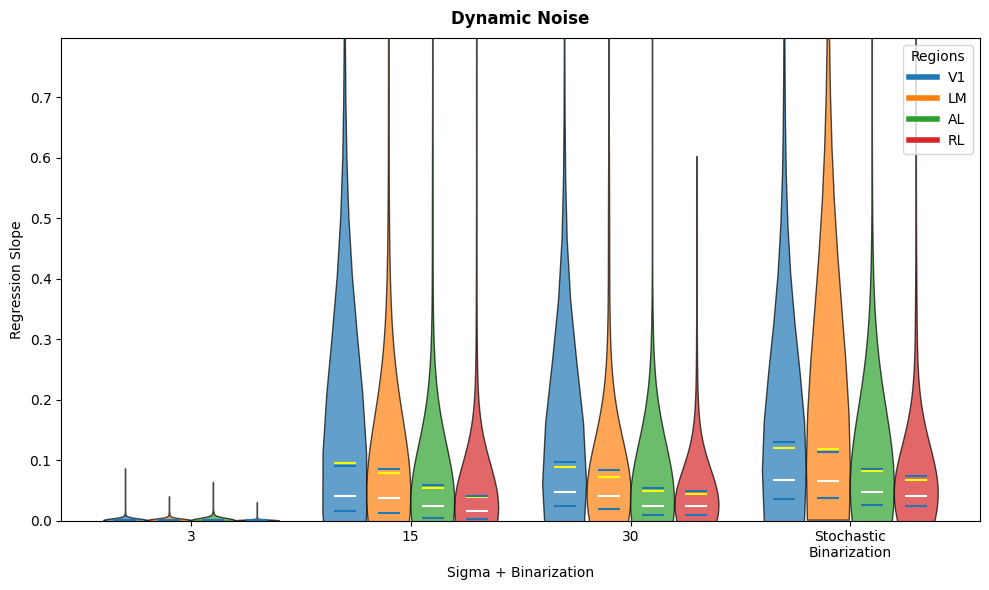

In [ ]:
violin_combined(scatter_means, scatter_vars, 'Dynamic Noise, Violin Plot 2', True)

In [ ]:
cscatter_means = [[c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1],
                 [c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2],
                 [c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3],
                 [c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]]


In [ ]:
scatter_vars = [[c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1],
               [c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2],
               [c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3],
               [c3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]]

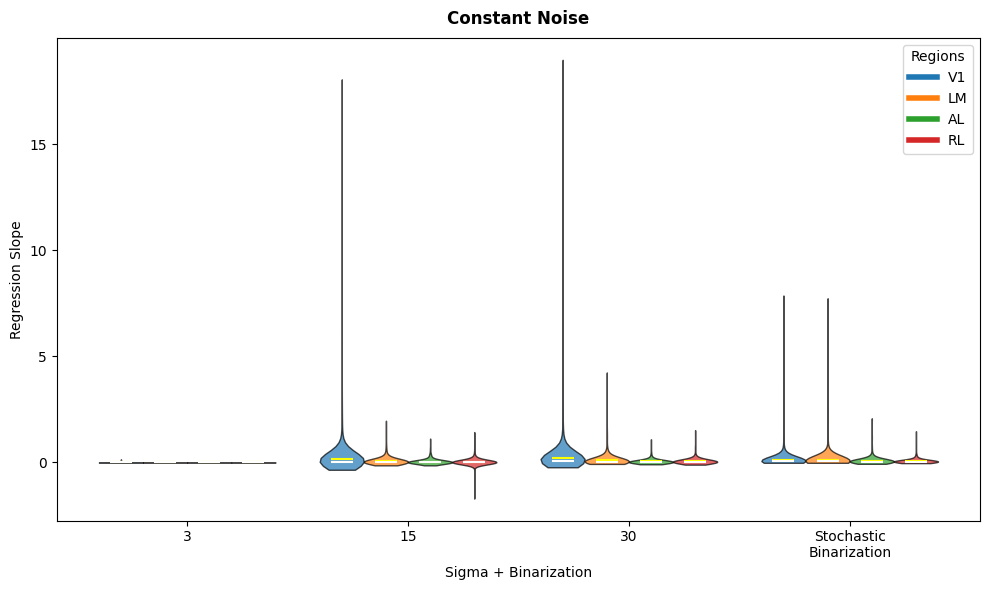

In [ ]:
violin_combined(cscatter_means, cscatter_vars, 'Constant Noise')

#### plot 4

In [ ]:
kde_means = [[d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1, c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1],
                 [d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2, c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2],
                 [d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3, c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3],
                 [d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4, c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]]


In [ ]:
kde_vars = [[d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1, c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1],
               [d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2, c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2],
               [d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3, c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3],
               [d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4, c3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]]

In [ ]:
# input should just be mean and var arrays or 2d lists
def kde_2x2(list_means, list_vars, title):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.0, title, ha='center', va='top', fontsize=12, fontweight = 'bold', bbox=dict(facecolor='white'))
    cmap = plt.get_cmap('viridis')
    row_colors = [cmap(0.2), cmap(0.4), cmap(0.6), cmap(0.8)] 
    for i in range(2):
        for j in range(2):
            idx = i * 2 + j
            ax = axes[i, j]

            means = list_means[idx]
            vars = list_vars[idx]

            # first get arrays of slopes from list
            kde_slopes = np.empty((sum(x.shape[1] for x in means)))

            reg_counter = 0
            for x, y in zip(means, vars):
                x = x.flatten()
                y = y.flatten()
                print(f'run {idx}, var of y = {np.var(y)}')
                regression = linregress(x, y)
                kde_slopes[reg_counter] = regression.slope
                reg_counter +=1

            print(f'for nulls: {np.any(np.isnan(kde_slopes))}\nfor infs: {np.any(np.isinf(kde_slopes))}')
            kde = gaussian_kde(kde_slopes)
            x_range = np.linspace(np.min(kde_slopes), np.max(kde_slopes), 750) # how many samples to generate?
            kde_values = kde(x_range)

            ax.plot(x_range, kde_values, color = row_colors[idx])
            ax.fill_between(x_range, kde_values, alpha = 0.5)

            if i == 1: ax.set_xlabel('Slope from\nprior regression')
            if j == 0: ax.set_ylabel('Density')

            if idx == 0: region_title = 'V1'
            elif idx == 1: region_title = 'LM'
            elif idx == 2: region_title = 'AL'
            else: region_title = 'RL'
            ax.set_title(f'Region: {region_title}')

    plt.tight_layout()
    plt.show()

run 0, var of y = 0.07623274649828485
run 0, var of y = 3902.7105526116125
run 0, var of y = 5826.4916261405715
run 0, var of y = 1629.4629332799336
run 0, var of y = 0.2626520773434943
run 0, var of y = 13395.3491342126
run 0, var of y = 9706.428724480871
run 0, var of y = 1850.0898648748157
for nulls: False
for infs: False
run 1, var of y = 0.03489340059365562
run 1, var of y = 31.13665868917507
run 1, var of y = 16.74758010667832
run 1, var of y = 6222.351370803318
run 1, var of y = 0.07690028861743498
run 1, var of y = 35.26799602634835
run 1, var of y = 171.17288307274697
run 1, var of y = 4909.444232731831
for nulls: False
for infs: False
run 2, var of y = 0.0019608008985847456
run 2, var of y = 18.55916253775208
run 2, var of y = 37.26912062285431
run 2, var of y = 25.516817742473147
run 2, var of y = 0.0013686130440646708
run 2, var of y = 3.6367429130883404
run 2, var of y = 3.9512594637980882
run 2, var of y = 22.33643212961825
for nulls: False
for infs: False
run 3, var of y

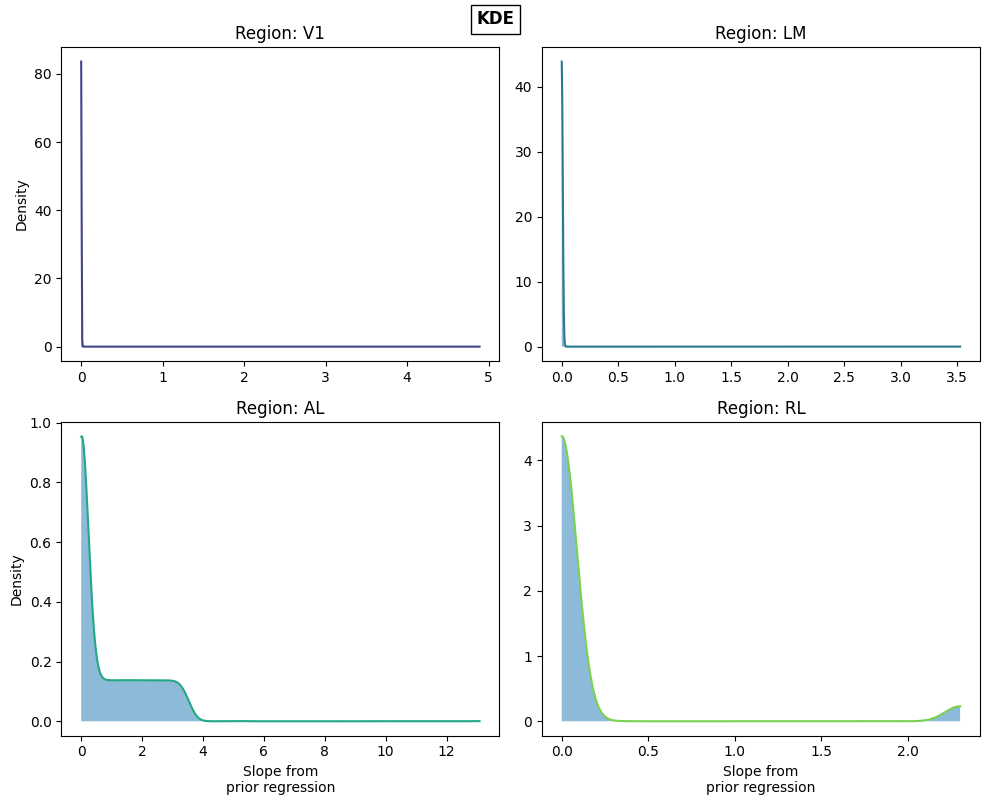

In [ ]:
kde_2x2(kde_means, kde_vars, 'KDE')

#### dynamic vs constant mean/var for sigma=15 and binarization

In [ ]:
x = dbin_mean.flatten()
y = cbin_mean.flatten()

In [ ]:
x_filtered, _ = remove_x(x, 'top', 10)
y_filtered = y[_]

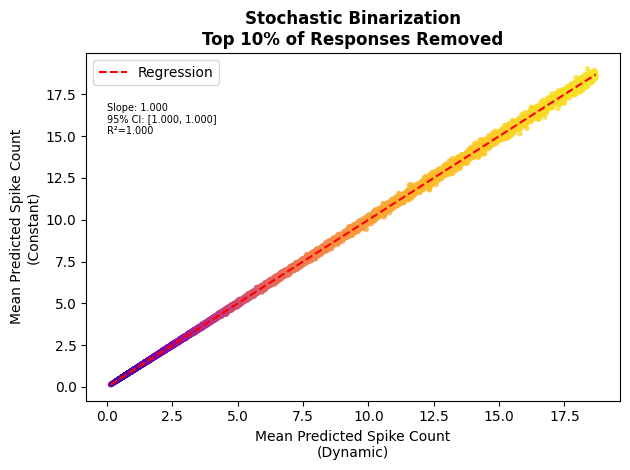

In [ ]:
cmap = plt.get_cmap('plasma')
linspace = np.linspace(np.min(x_filtered), .95, len(x_filtered))
colors = cmap(linspace)
plt.scatter(x_filtered, y_filtered, color = colors, marker = '.', alpha = 0.7)

linregress_result = linregress(x_filtered, y_filtered)
y_pred = linregress_result.intercept + linregress_result.slope * x_filtered
plt.plot(x_filtered, y_pred, 'r--', label = 'Regression')

rsq = linregress_result.rvalue ** 2
plt.text(0, 17, f"Slope: {linregress_result.slope:.3f}\n95% CI: [{linregress_result.slope - 1.96*linregress_result.stderr:.3f}, {linregress_result.slope + 1.96*linregress_result.stderr:.3f}]\nR²={rsq:.3f}", 
        fontsize=7, verticalalignment='top')

plt.legend()
plt.title('Stochastic Binarization\nTop 10% of Responses Removed', fontweight = 'bold')
plt.xlabel('Mean Predicted Spike Count\n(Dynamic)')
plt.ylabel('Mean Predicted Spike Count\n(Constant)')
plt.tight_layout()
plt.show()

In [ ]:
x = d15_mean.flatten()
y = c15_mean.flatten()

In [ ]:
x_filtered, _ = remove_x(x, 'top', 10)
y_filtered = y[_]

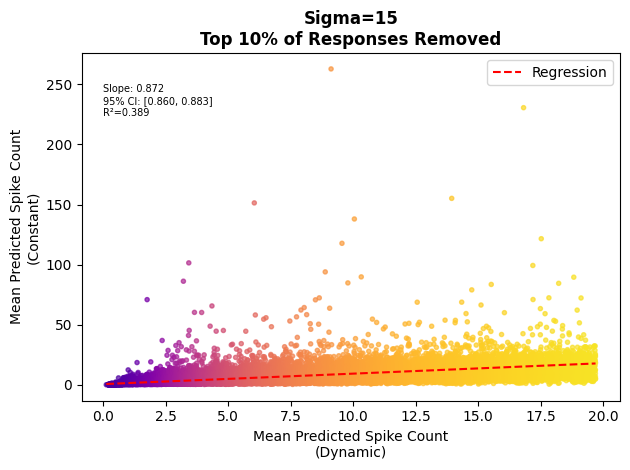

In [ ]:

cmap = plt.get_cmap('plasma')
linspace = np.linspace(np.min(x_filtered), .95, len(x_filtered))
colors = cmap(linspace)
plt.scatter(x_filtered, y_filtered, color = colors, marker = '.', alpha = 0.7)

linregress_result = linregress(x_filtered, y_filtered)
y_pred = linregress_result.intercept + linregress_result.slope * x_filtered
plt.plot(x_filtered, y_pred, 'r--', label = 'Regression')

rsq = linregress_result.rvalue ** 2
plt.text(0, 250, f"Slope: {linregress_result.slope:.3f}\n95% CI: [{linregress_result.slope - 1.96*linregress_result.stderr:.3f}, {linregress_result.slope + 1.96*linregress_result.stderr:.3f}]\nR²={rsq:.3f}", 
        fontsize=7, verticalalignment='top')

plt.legend()
plt.title('Sigma=15\nTop 10% of Responses Removed', fontweight = 'bold')
plt.xlabel('Mean Predicted Spike Count\n(Dynamic)')
plt.ylabel('Mean Predicted Spike Count\n(Constant)')
plt.tight_layout()
plt.show()

In [ ]:
x = dbin_var.flatten()
y = cbin_var.flatten()

In [ ]:
x_filtered, _ = remove_x(x, 'top', 10)
y_filtered = y[_]

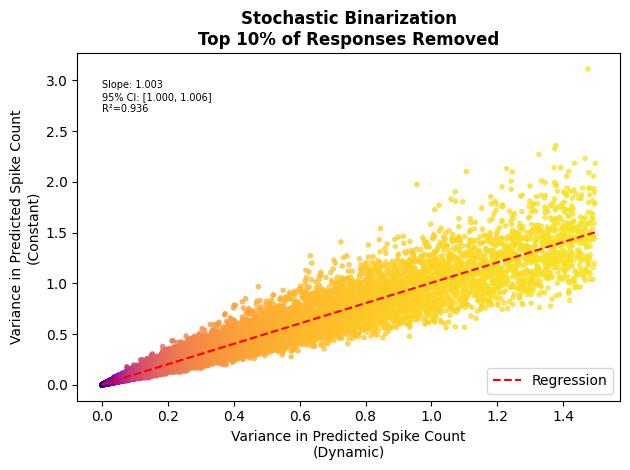

In [ ]:
cmap = plt.get_cmap('plasma')
linspace = np.linspace(np.min(x_filtered), .95, len(x_filtered))
colors = cmap(linspace)
plt.scatter(x_filtered, y_filtered, color = colors, marker = '.', alpha = 0.7)

linregress_result = linregress(x_filtered, y_filtered)
y_pred = linregress_result.intercept + linregress_result.slope * x_filtered
plt.plot(x_filtered, y_pred, 'r--', label = 'Regression')

rsq = linregress_result.rvalue ** 2

plt.text(0, 3, f"Slope: {linregress_result.slope:.3f}\n95% CI: [{linregress_result.slope - 1.96*linregress_result.stderr:.3f}, {linregress_result.slope + 1.96*linregress_result.stderr:.3f}]\nR²={rsq:.3f}", 
        fontsize=7, verticalalignment='top')

plt.legend()
plt.title('Stochastic Binarization\nTop 10% of Responses Removed', fontweight = 'bold')
plt.xlabel('Variance in Predicted Spike Count\n(Dynamic)')
plt.ylabel('Variance in Predicted Spike Count\n(Constant)')
plt.tight_layout()
plt.show()

In [ ]:
x = d15_var.flatten()
y = c15_var.flatten()

In [ ]:
x_filtered, _ = remove_x(x, 'top', 10)
y_filtered = y[_]

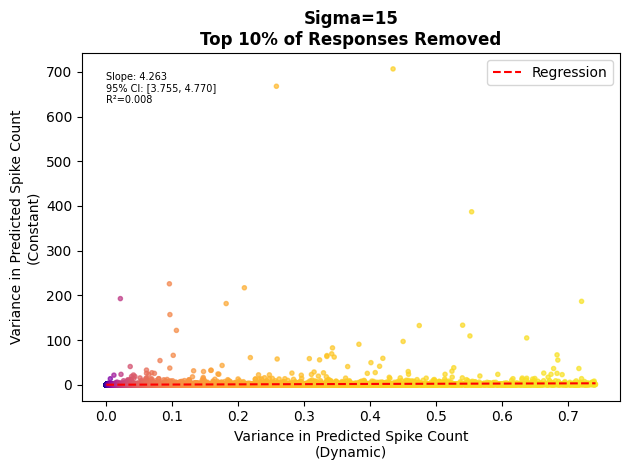

In [ ]:
cmap = plt.get_cmap('plasma')
linspace = np.linspace(np.min(x_filtered), .95, len(x_filtered))
colors = cmap(linspace)
plt.scatter(x_filtered, y_filtered, color = colors, marker = '.', alpha = 0.7)

linregress_result = linregress(x_filtered, y_filtered)
y_pred = linregress_result.intercept + linregress_result.slope * x_filtered
plt.plot(x_filtered, y_pred, 'r--', label = 'Regression')

rsq = linregress_result.rvalue ** 2

plt.text(0, 700, f"Slope: {linregress_result.slope:.3f}\n95% CI: [{linregress_result.slope - 1.96*linregress_result.stderr:.3f}, {linregress_result.slope + 1.96*linregress_result.stderr:.3f}]\nR²={rsq:.3f}", 
        fontsize=7, verticalalignment='top')

plt.legend()
plt.title('Sigma=15\nTop 10% of Responses Removed', fontweight = 'bold')
plt.xlabel('Variance in Predicted Spike Count\n(Dynamic)')
plt.ylabel('Variance in Predicted Spike Count\n(Constant)')
plt.tight_layout()
plt.show()